In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile, os

zip_path = '/content/drive/MyDrive/archive.zip'
extract_path = '/content/package_dataset'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, 'dataset')
print(os.listdir(dataset_path))

['damaged', 'intact']


In [ ]:
from PIL import Image

removed = []
for cls in ['damaged', 'intact']:
    folder = os.path.join(dataset_path, cls)
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            with Image.open(fpath) as img:
                img.verify()
            with Image.open(fpath) as img:
                img.convert('RGB')
        except Exception:
            removed.append(fpath)
            os.remove(fpath)
print('Removed:', len(removed))


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Removed: 0


In [ ]:
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        print(folder, ':', len(os.listdir(folder_path)), 'files')


damaged : 4258 files
intact : 3205 files


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path, validation_split=0.30, subset='training', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path, validation_split=0.30, subset='validation', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

CLASS_NAMES = train_ds.class_names
print('Class names:', CLASS_NAMES)

temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()
val_batches = temp_batches // 2
val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


Found 7424 files belonging to 2 classes.
Using 5197 files for training.
Found 7424 files belonging to 2 classes.
Using 2227 files for validation.
Class names: ['damaged', 'intact']


In [ ]:
num_damaged = len(os.listdir(os.path.join(dataset_path, 'damaged')))
num_intact = len(os.listdir(os.path.join(dataset_path, 'intact')))
total = num_damaged + num_intact
num_classes = 2

class_weight = {
    0: total / (num_classes * num_damaged),
    1: total / (num_classes * num_intact)
}
print(class_weight)


{0: 0.8763503992484735, 1: 1.1642745709828393}


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# Load the pretrained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Build the complete sequential model
pretrained_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
pretrained_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the summary
pretrained_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history_pretrained = pretrained_model.fit(
    train_ds, validation_data=val_ds, epochs=10, class_weight=class_weight
)


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 63s 274ms/step - accuracy: 0.7856 - loss: 0.7009 - val_accuracy: 0.8330 - val_loss: 0.3785
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 259ms/step - accuracy: 0.8411 - loss: 0.3599 - val_accuracy: 0.8411 - val_loss: 0.3602
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 245ms/step - accuracy: 0.8613 - loss: 0.3264 - val_accuracy: 0.8500 - val_loss: 0.3192
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.8815 - loss: 0.2966 - val_accuracy: 0.8607 - val_loss: 0.3161
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 248ms/step - accuracy: 0.8857 - loss: 0.2790 - val_accuracy: 0.8598 - val_loss: 0.3143
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 266ms/step - accuracy: 0.8928 - loss: 0.2517 - val_accuracy: 0.8509 - val_loss: 0.3250
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 250ms/step - accuracy: 0.8967 - loss: 0.2466 - val_accuracy: 0.8723 - val_loss: 0.3027
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 247ms/step - accuracy: 0.8976 - loss: 0

In [ ]:
scratch_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

scratch_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
scratch_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_scratch = scratch_model.fit(
    train_ds, validation_data=val_ds, epochs=15, class_weight=class_weight
)


Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 136ms/step - accuracy: 0.7119 - loss: 0.5241 - val_accuracy: 0.7920 - val_loss: 0.4080
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 101ms/step - accuracy: 0.7943 - loss: 0.4065 - val_accuracy: 0.7982 - val_loss: 0.4090
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - accuracy: 0.8270 - loss: 0.3604 - val_accuracy: 0.8134 - val_loss: 0.4088
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - accuracy: 0.8574 - loss: 0.3189 - val_accuracy: 0.8107 - val_loss: 0.4403
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - accuracy: 0.8715 - loss: 0.2967 - val_accuracy: 0.8009 - val_loss: 0.4707
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - accuracy: 0.8930 - loss: 0.2475 - val_accuracy: 0.8313 - val_loss: 0.4506
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - accuracy: 0.9167 - loss: 0.2074 - val_accuracy: 0.8411 - val_loss: 0.4616
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - accuracy: 0.9284 - loss: 0.1841 

In [ ]:
MODEL_DIR = '/content/drive/MyDrive/package_damage_models'
os.makedirs(MODEL_DIR, exist_ok=True)

pretrained_path = os.path.join(MODEL_DIR, 'pretrained_mobilenetv2.keras')
scratch_path = os.path.join(MODEL_DIR, 'scratch_cnn.keras')

pretrained_model.save(pretrained_path)
scratch_model.save(scratch_path)
print('Saved:', pretrained_path)
print('Saved:', scratch_path)


Saved: /content/drive/MyDrive/package_damage_models/pretrained_mobilenetv2.keras
Saved: /content/drive/MyDrive/package_damage_models/scratch_cnn.keras


In [ ]:
model = tf.keras.models.load_model(pretrained_path)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,912,069 (56.89 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 131,588 (514.02 KB)

35/35 ━━━━━━━━━━━━━━━━━━━━ 26s 608ms/step - accuracy: 0.8717 - loss: 0.3122
Test accuracy: 0.8717253804206848
Test loss: 0.312249094247818
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 230ms/step
              precision    recall  f1-score   support

     damaged       0.55      0.52      0.54       624
      intact       0.43      0.46      0.44       483

    accuracy                           0.49      1107
   macro avg       0.49      0.49      0.49      1107
weighted avg       0.50      0.49      0.50      1107



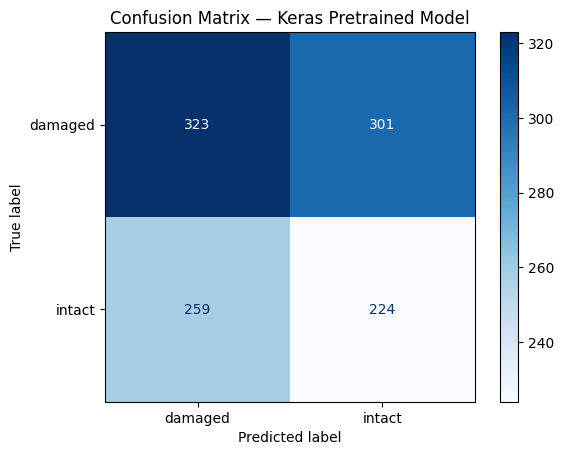

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

test_loss, test_acc = model.evaluate(test_ds)
print('Test accuracy:', test_acc)
print('Test loss:', test_loss)

y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0).flatten()
y_pred_prob = model.predict(test_ds)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Keras Pretrained Model')
plt.show()


In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_package_image_keras(img_path, model=model, img_size=IMG_SIZE, class_names=CLASS_NAMES):
    img = keras_image.load_img(img_path, target_size=img_size)
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prob = model.predict(img_array, verbose=0)[0][0]
    label = class_names[1] if prob > 0.5 else class_names[0]
    confidence = prob if prob > 0.5 else 1 - prob

    plt.imshow(img)
    plt.axis('off')
    plt.title(f'{label} ({confidence:.2%})')
    plt.show()
    print(label, confidence)
    return label, float(confidence)


Saving In519_Product7_l.jpg to In519_Product7_l.jpg


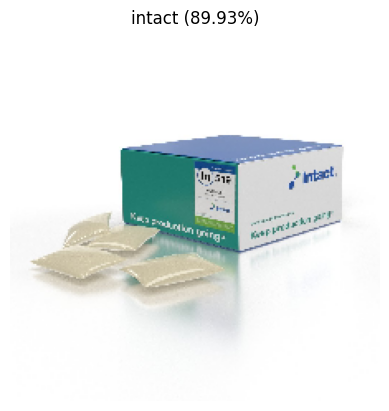

intact 0.89933807


('intact', 0.8993380665779114)

In [ ]:
from google.colab import files

uploaded = files.upload()
new_image_path = list(uploaded.keys())[0]
predict_package_image_keras(new_image_path)


In [ ]:
import pandas as pd
from datetime import datetime

results = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'model': 'Pretrained MobileNetV2',
    'test_accuracy': round(test_acc, 4),
    'test_loss': round(test_loss, 4),
    'precision_damaged': round(report_dict['damaged']['precision'], 4),
    'recall_damaged': round(report_dict['damaged']['recall'], 4),
    'f1_damaged': round(report_dict['damaged']['f1-score'], 4),
    'precision_intact': round(report_dict['intact']['precision'], 4),
    'recall_intact': round(report_dict['intact']['recall'], 4),
    'f1_intact': round(report_dict['intact']['f1-score'], 4),
}

results_df = pd.DataFrame([results])
display(results_df)

results_csv_path = os.path.join(MODEL_DIR, 'results_log.csv')
if os.path.exists(results_csv_path):
    existing = pd.read_csv(results_csv_path)
    results_df = pd.concat([existing, results_df], ignore_index=True)
results_df.to_csv(results_csv_path, index=False)
print('Saved:', results_csv_path)


,timestamp,model,test_accuracy,test_loss,precision_damaged,recall_damaged,f1_damaged,precision_intact,recall_intact,f1_intact
0,2026-08-25 13:20,Pretrained MobileNetV2,0.8717,0.3122,0.555,0.5176,0.5357,0.4267,0.4638,0.4444


Saved: /content/drive/MyDrive/package_damage_models/results_log.csv


In [ ]:
!pip install ultralytics -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 5.9 MB/s eta 0:00:00


In [ ]:
import shutil, random

yolo_dst = '/content/yolo_dataset'
for split in ['train', 'val']:
    for cls in ['damaged', 'intact']:
        os.makedirs(f'{yolo_dst}/{split}/{cls}', exist_ok=True)

random.seed(42)
for cls in ['damaged', 'intact']:
    files_ = os.listdir(os.path.join(dataset_path, cls))
    random.shuffle(files_)
    split_idx = int(0.7 * len(files_))
    for f in files_[:split_idx]:
        shutil.copy(os.path.join(dataset_path, cls, f), f'{yolo_dst}/train/{cls}/{f}')
    for f in files_[split_idx:]:
        shutil.copy(os.path.join(dataset_path, cls, f), f'{yolo_dst}/val/{cls}/{f}')


In [ ]:
from ultralytics import YOLO

yolo_model = YOLO('yolov8n-cls.pt')
yolo_results = yolo_model.train(data=yolo_dst, epochs=15, imgsz=224)


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=tor

In [ ]:
yolo_best_src = '/content/runs/classify/train/weights/best.pt'
yolo_best_dst = os.path.join(MODEL_DIR, 'yolov8_cls_best.pt')
shutil.copy(yolo_best_src, yolo_best_dst)
print('Saved:', yolo_best_dst)


Saved: /content/drive/MyDrive/package_damage_models/yolov8_cls_best.pt


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.9):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


<IPython.core.display.Javascript object>


image 1/1 /content/live_capture.jpg: 224x224 damaged 0.92, intact 0.08, 3.0ms
Speed: 5.5ms preprocess, 3.0ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


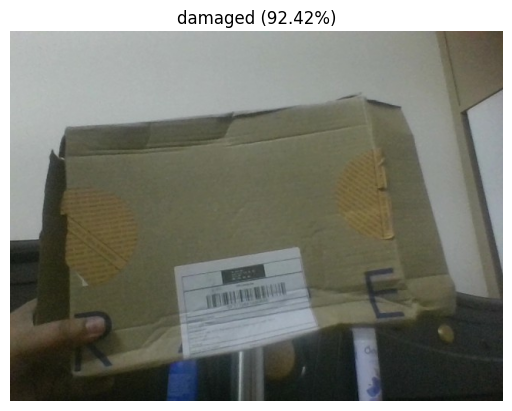

Prediction: damaged | Confidence: 0.9241542220115662


In [ ]:
from ultralytics import YOLO

yolo_live_model = YOLO(yolo_best_dst)

live_img_path = take_photo('live_capture.jpg')

results = yolo_live_model.predict(live_img_path, imgsz=224)
r = results[0]
pred_label = r.names[r.probs.top1]
pred_conf = float(r.probs.top1conf)

img = Image.open(live_img_path)
plt.imshow(img)
plt.axis('off')
plt.title(f'{pred_label} ({pred_conf:.2%})')
plt.show()

print('Prediction:', pred_label, '| Confidence:', pred_conf)


In [ ]:
from google.colab import files

uploaded_video = files.upload()
video_path = list(uploaded_video.keys())[0]
print('Uploaded:', video_path)

Saving istockphoto-682889488-640_adpp_is.mp4 to istockphoto-682889488-640_adpp_is.mp4
Uploaded: istockphoto-682889488-640_adpp_is.mp4


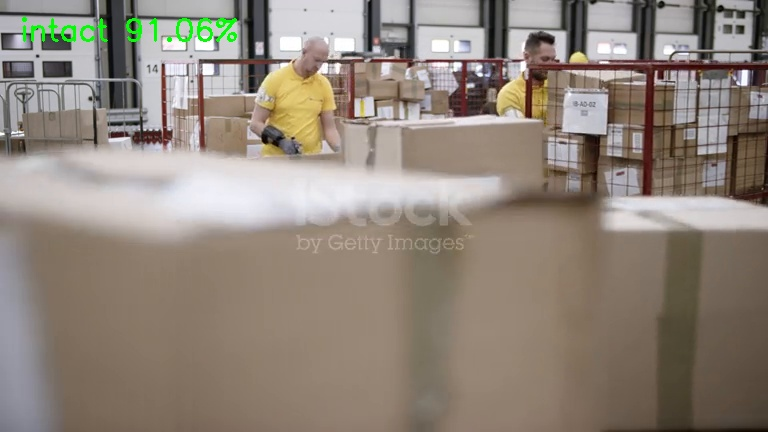

Frame 495/496 | intact | 91.06%
Done. Saved annotated video to: /content/output_detected.mp4


In [ ]:
import cv2
from IPython.display import clear_output, Image as IPImage, display

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'fps={fps}, size={width}x{height}, total_frames={total_frames}')

output_path = '/content/output_detected.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps if fps > 0 else 20, (width, height))

PROCESS_EVERY_N = 5   # run YOLO every Nth frame to keep it fast; other frames reuse the last label
SHOW_PREVIEW = True    # set False to just process silently and save the output video

frame_idx = 0
last_label, last_conf = 'intact', 0.0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % PROCESS_EVERY_N == 0:
        results = yolo_live_model.predict(frame, imgsz=224, verbose=False)
        r = results[0]
        last_label = r.names[r.probs.top1]
        last_conf = float(r.probs.top1conf)

    color = (0, 0, 255) if last_label == 'damaged' else (0, 255, 0)
    cv2.putText(frame, f'{last_label} {last_conf:.2%}', (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)

    out.write(frame)

    if SHOW_PREVIEW and frame_idx % PROCESS_EVERY_N == 0:
        _, buf = cv2.imencode('.jpg', frame)
        clear_output(wait=True)
        display(IPImage(data=buf.tobytes()))
        print(f'Frame {frame_idx}/{total_frames} | {last_label} | {last_conf:.2%}')

    frame_idx += 1

cap.release()
out.release()
print('Done. Saved annotated video to:', output_path)


In [ ]:
from google.colab import files
files.download(output_path)

# or, to save to Drive instead:
# import shutil
# shutil.copy(output_path, '/content/drive/MyDrive/output_detected.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>